✅ Imports chargés.

✅ Connexion SQL Server établie.

─── Tables disponibles ───
TABLE_SCHEMA              TABLE_NAME
         dbo         Dim_Beneficiary
         dbo            Dim_Category
         dbo           Dim_Complaint
         dbo                Dim_Date
         dbo          Dim_evaluation
         dbo              Dim_Events
         dbo             Dim_Holiday
         dbo            Dim_provider
         dbo              Dim_Region
         dbo             Dim_Service
         dbo              Dim_Status
         dbo         Dim_SubCategory
         dbo        Fact_EventBudget
         dbo Fact_Marketing_Spending
         dbo        Fact_Reservation
         dbo       Fact_ServicePrice
         dbo           Fact_Visitors
✅ Connexion fermée.

─── Tables chargées ───
  dim_evaluation          11962 lignes ×  3 colonnes
  Dim_Events              11957 lignes ×  3 colonnes
  Dim_Service              2500 lignes ×  4 colonnes
  Dim_Status                  3 lignes ×  3 colonn

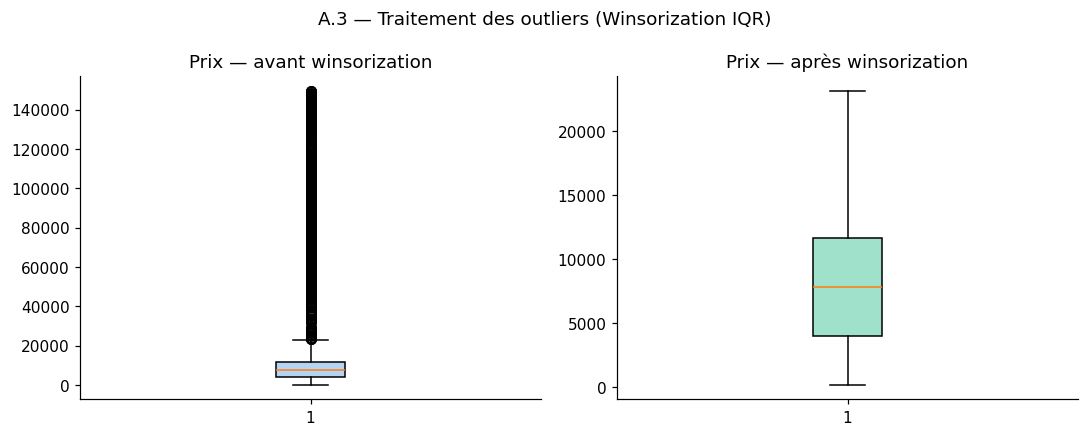

✅ Après nettoyage : 18000 lignes × 25 colonnes

─── A.4 Construction des profils ───
✅ Profil client      : 500 clients × 4 features
✅ Profil prestataire : 80 prestataires × 7 features


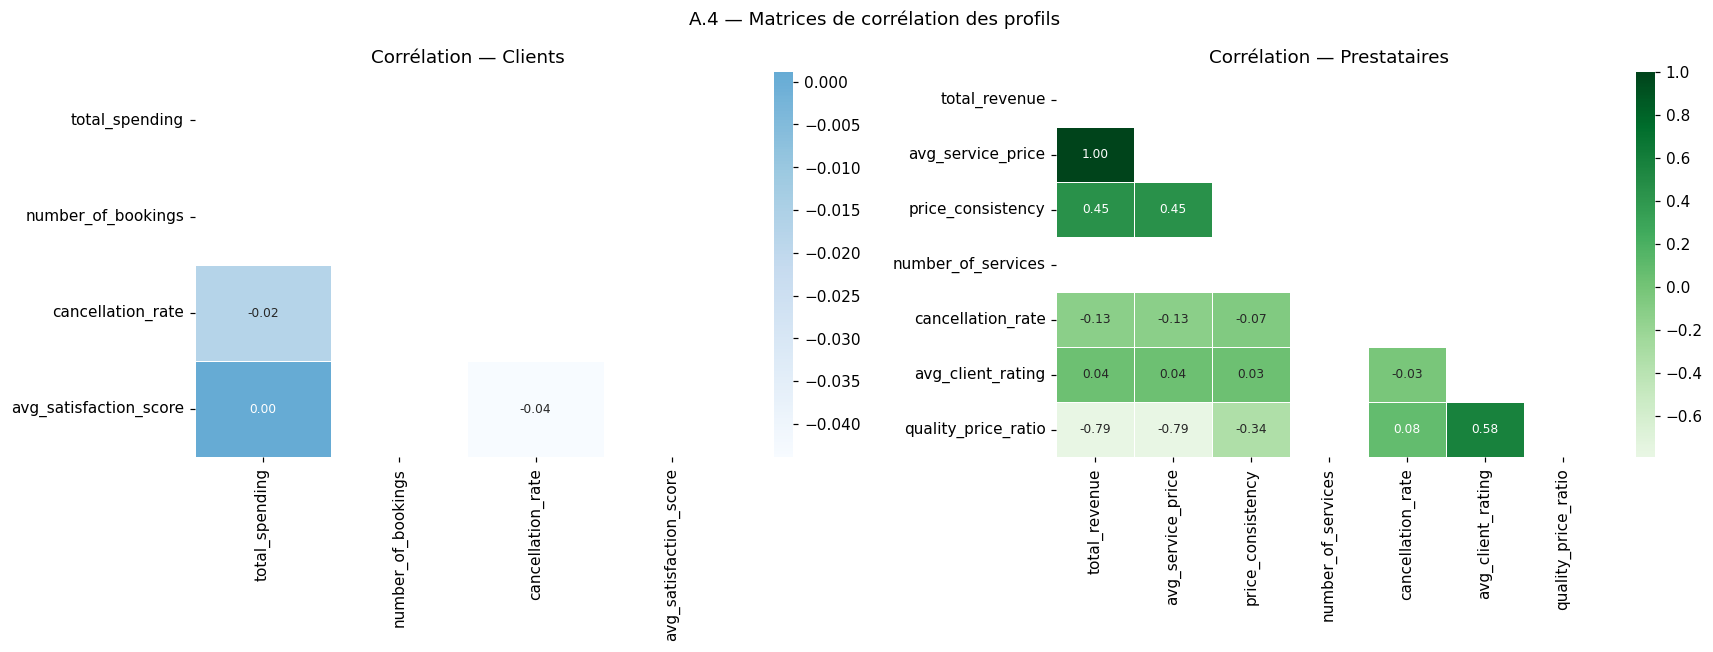


E — CLUSTERING — SEGMENTATION CLIENTS & PRESTATAIRES

  Clustering — Clients


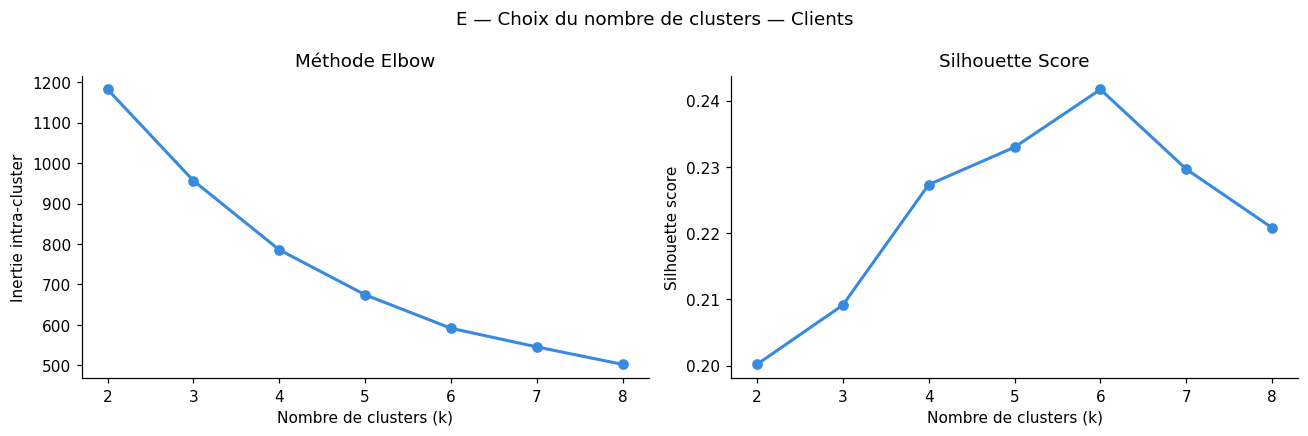

  Meilleur k : 6
  K-Means      — Silhouette: 0.2417 | Davies-Bouldin: 1.1111
  Hiérarchique — Silhouette: 0.1933 | Davies-Bouldin: 1.2611


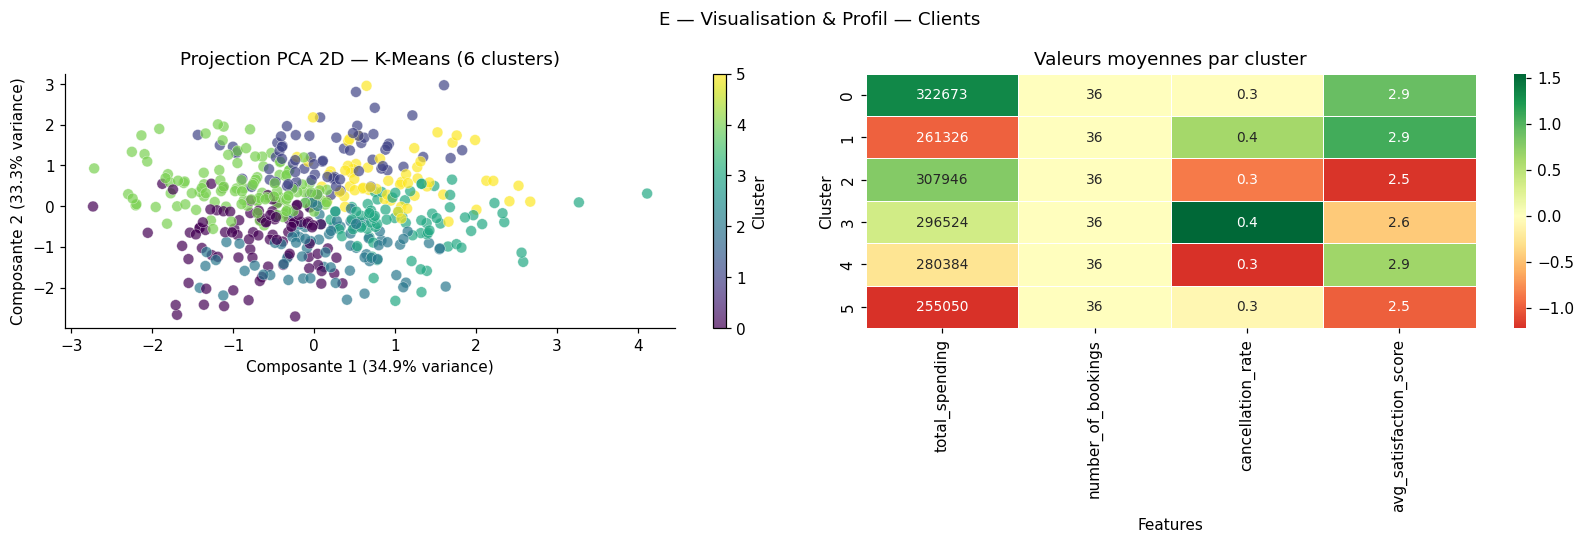

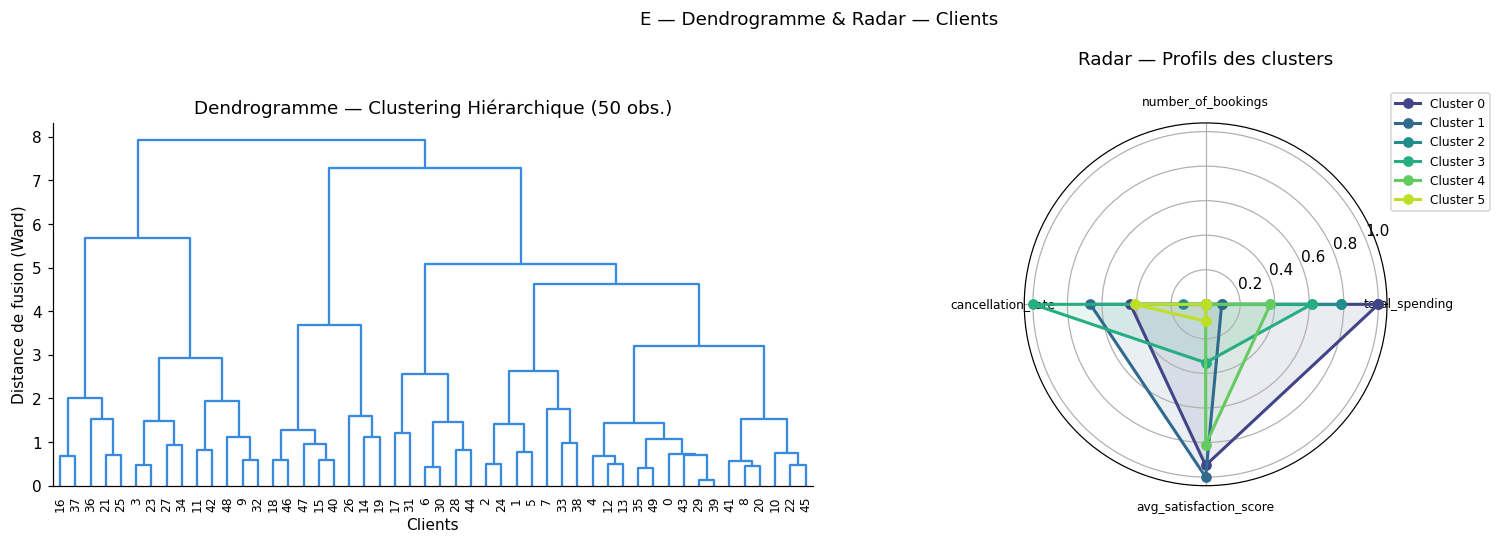


  Clustering — Prestataires


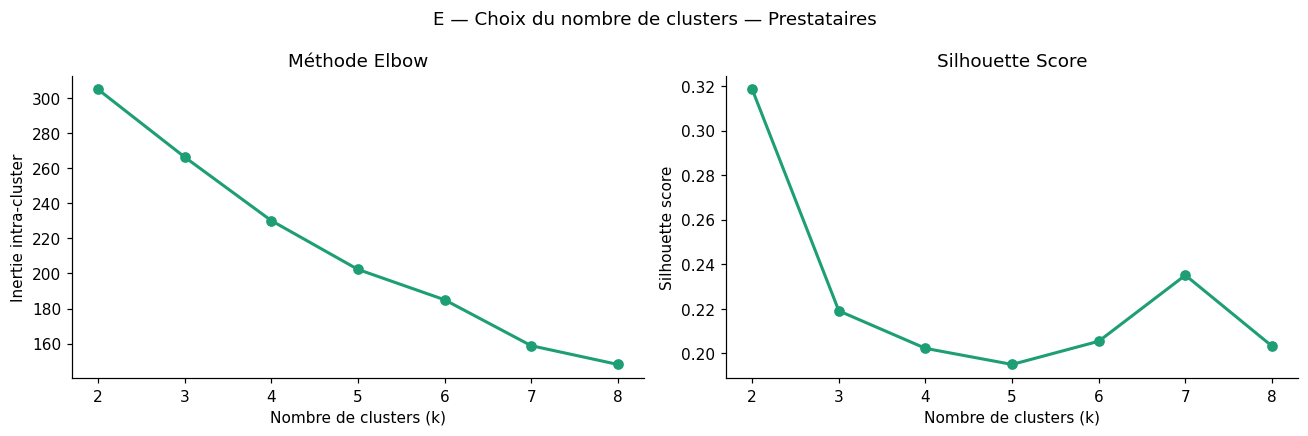

  Meilleur k : 2
  K-Means      — Silhouette: 0.3185 | Davies-Bouldin: 1.2121
  Hiérarchique — Silhouette: 0.2680 | Davies-Bouldin: 1.3649


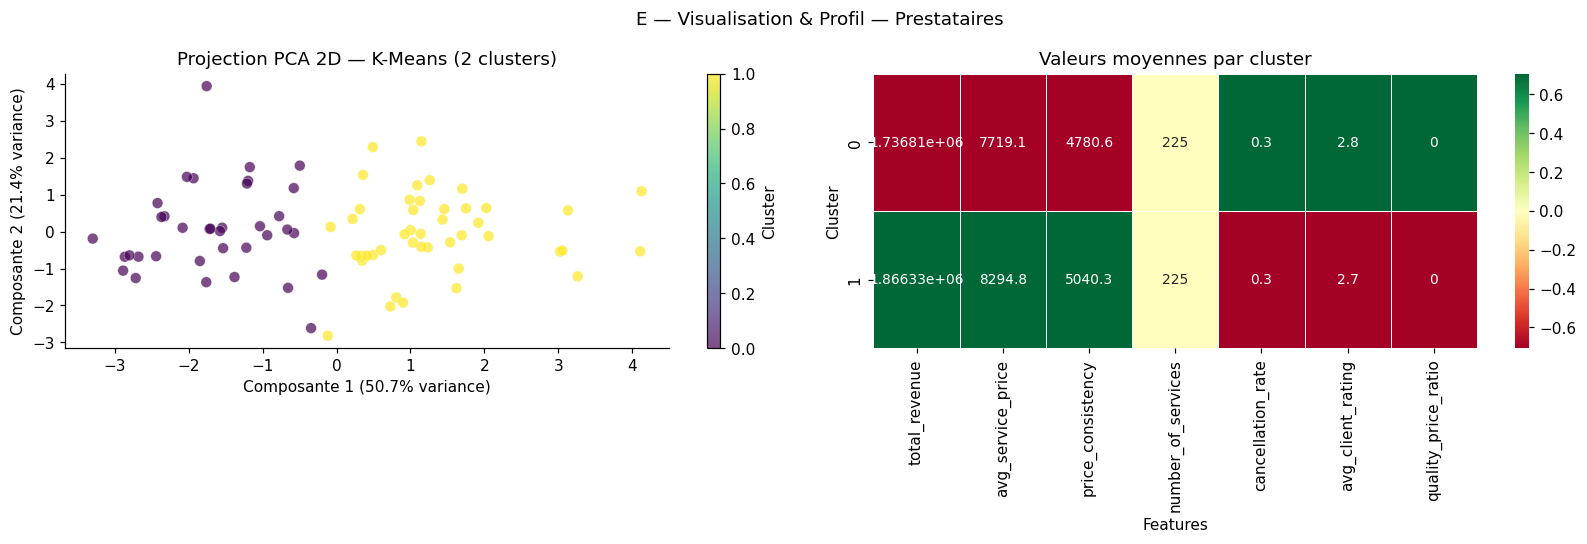

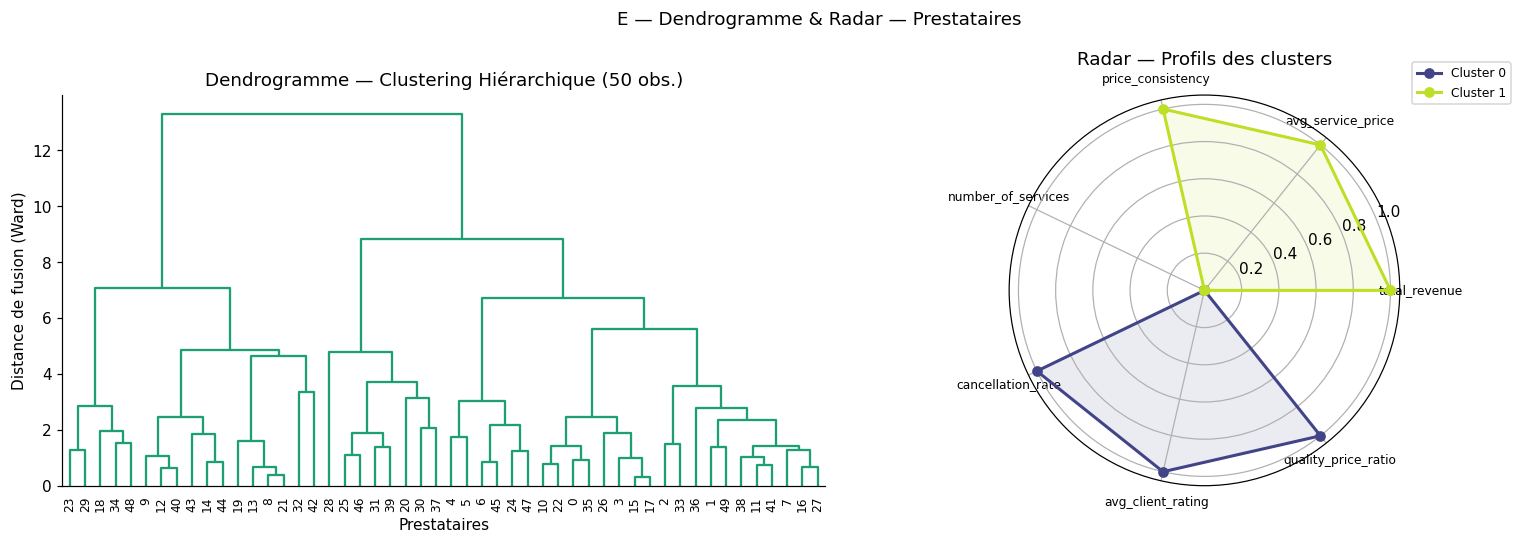


✅ Labels clusters attachés au DataFrame central.

─── Comparaison Clustering ───
Entité             Méthode             Clusters   Silhouette
------------------------------------------------------------
Clients            K-Means                    6       0.2417
                   Hiérarchique               6       0.1933
Prestataires       K-Means                    2       0.3185
                   Hiérarchique               2       0.2680

─── Profil moyen par cluster client ───
                total_spending  number_of_bookings  cancellation_rate  avg_satisfaction_score
kmeans_cluster                                                                               
0                    322672.82                36.0               0.34                    2.91
1                    261325.51                36.0               0.38                    2.94
2                    307946.09                36.0               0.29                    2.45
3                    296524.22           

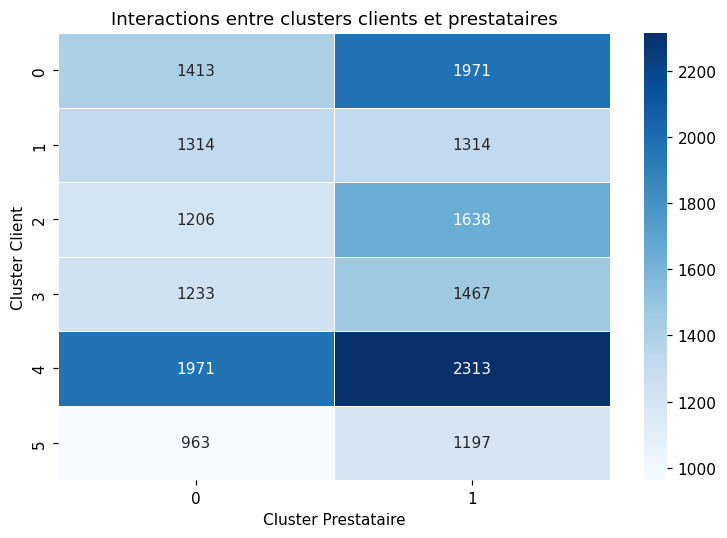


✅ Segmentation terminée.


In [3]:
# =============================================================================
# SEGMENTATION CLIENTS & PRESTATAIRES
# Sections nécessaires uniquement : A (préparation) + E (clustering)
# =============================================================================

# =============================================================================
# 0. IMPORTS
# =============================================================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc

from sklearn.preprocessing  import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute         import SimpleImputer
from sklearn.cluster        import KMeans, AgglomerativeClustering
from sklearn.decomposition  import PCA
from sklearn.metrics        import silhouette_score, davies_bouldin_score

import scipy.cluster.hierarchy as sch

plt.rcParams.update({'figure.dpi': 110,
                     'axes.spines.top': False,
                     'axes.spines.right': False})
SEED = 42

CLR_CLIENT   = '#378ADD'
CLR_PROVIDER = '#1D9E75'

print("✅ Imports chargés.\n")


# =============================================================================
# A.1 — CHARGEMENT DES DONNÉES DEPUIS SQL SERVER
# =============================================================================
SERVER   = "DESKTOP-SOIS8T7"
DATABASE = "DW"

conn = pyodbc.connect(
    f"DRIVER={{SQL Server}};"
    f"SERVER={SERVER};"
    f"DATABASE={DATABASE};"
    f"Trusted_Connection=yes;"
)
print("✅ Connexion SQL Server établie.")

# --- Vérification optionnelle des tables disponibles ---
tables_dispo = pd.read_sql("""
    SELECT TABLE_SCHEMA, TABLE_NAME
    FROM INFORMATION_SCHEMA.TABLES
    WHERE TABLE_TYPE = 'BASE TABLE'
    ORDER BY TABLE_SCHEMA, TABLE_NAME
""", conn)
print("\n─── Tables disponibles ───")
print(tables_dispo.to_string(index=False))

# =============================================================================
# CHARGEMENT DES TABLES  ← "dim_evaluation" corrigé ici
# =============================================================================
dim_evaluation  = pd.read_sql("SELECT * FROM dim_evaluation",  conn)
dim_events      = pd.read_sql("SELECT * FROM Dim_Events",      conn)
dim_service     = pd.read_sql("SELECT * FROM Dim_Service",     conn)
dim_status      = pd.read_sql("SELECT * FROM Dim_Status",      conn)
dim_date        = pd.read_sql("SELECT * FROM Dim_Date",        conn)
dim_provider    = pd.read_sql("SELECT * FROM Dim_Provider",   conn)

fact_reservation  = pd.read_sql("SELECT * FROM Fact_Reservation",  conn)
fact_serviceprice = pd.read_sql("SELECT * FROM Fact_ServicePrice",  conn)

conn.close()
print("✅ Connexion fermée.")


# =============================================================================
# NETTOYAGE DES COLONNES
# =============================================================================
def normalize_columns(df):
    df.columns = (
        df.columns
          .str.strip()
          .str.lower()
          .str.replace(r'_fk$', '', regex=True)
    )
    return df

dim_evaluation  = normalize_columns(dim_evaluation)
dim_events      = normalize_columns(dim_events)
dim_service     = normalize_columns(dim_service)
dim_status      = normalize_columns(dim_status)
dim_date        = normalize_columns(dim_date)
dim_provider    = normalize_columns(dim_provider)
fact_reservation  = normalize_columns(fact_reservation)
fact_serviceprice = normalize_columns(fact_serviceprice)

# =============================================================================
# VÉRIFICATION
# =============================================================================
tables = {
    "dim_evaluation"   : dim_evaluation,
    "Dim_Events"       : dim_events,
    "Dim_Service"      : dim_service,
    "Dim_Status"       : dim_status,
    "Dim_Date"         : dim_date,
    "Dim_Providers"    : dim_provider,
    "Fact_Reservation" : fact_reservation,
    "Fact_ServicePrice": fact_serviceprice,
}

print("\n─── Tables chargées ───")
for name, df in tables.items():
    print(f"  {name:<22} {df.shape[0]:>6} lignes × {df.shape[1]:>2} colonnes")

print("\n✅ Importation terminée.")


# =============================================================================
# A.2 — MERGE
# =============================================================================
df = fact_reservation.copy()

merges = [
    (dim_service,    'id_service',    ''),
    (dim_status,     'id_status',     '_sts'),
    (dim_date,       'id_date',       '_dt'),
    (dim_evaluation, 'id_evaluation', '_ev'),
    (dim_events,     'id_event',      '_evt'),
    (dim_provider,   'id_provider',   '_prov'),
]
for dim, key, sfx in merges:
    if key in df.columns and key in dim.columns:
        df = df.merge(dim, on=key, how='left', suffixes=('', sfx))

if 'id_servicefk' in fact_serviceprice.columns:
    fact_serviceprice = fact_serviceprice.rename(
        columns={'id_servicefk': 'id_service'})
if ('id_service' in fact_serviceprice.columns and
        'price' in fact_serviceprice.columns):
    svc_cat = (fact_serviceprice
               .groupby('id_service')['price']
               .agg(catalog_mean='mean').reset_index())
    df = df.merge(svc_cat, on='id_service', how='left')

df = df.rename(columns={'final_price': 'price'})
print(f"✅ DataFrame brut : {df.shape[0]} lignes × {df.shape[1]} colonnes")


# =============================================================================
# A.3 — NETTOYAGE
# =============================================================================
print("\n─── A.3 Nettoyage ───")

# Winsorization IQR sur le prix
Q1, Q3       = df['price'].quantile(0.25), df['price'].quantile(0.75)
IQR          = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
price_before = df['price'].copy()
df['price']  = df['price'].clip(lower=lower, upper=upper)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(price_before.dropna(), patch_artist=True,
                boxprops=dict(facecolor='#B5D4F4'))
axes[0].set_title("Prix — avant winsorization")
axes[1].boxplot(df['price'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='#9FE1CB'))
axes[1].set_title("Prix — après winsorization")
plt.suptitle("A.3 — Traitement des outliers (Winsorization IQR)")
plt.tight_layout(); plt.show()

# Encodage ordinal
if 'rating' in df.columns:
    oe_r = OrdinalEncoder(
        categories=[['Bad', 'Average', 'Good']],
        handle_unknown='use_encoded_value', unknown_value=-1)
    df['rating_enc'] = oe_r.fit_transform(df[['rating']])

if 'status' in df.columns:
    oe_s = OrdinalEncoder(
        categories=[['pending', 'confirmed', 'cancelled']],
        handle_unknown='use_encoded_value', unknown_value=-1)
    df['status_enc'] = oe_s.fit_transform(df[['status']])

# Imputation médiane
num_cols     = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols] = SimpleImputer(strategy='median').fit_transform(df[num_cols])

# Encodage label
for col in df.select_dtypes(include='object').columns:
    df[col + '_enc'] = LabelEncoder().fit_transform(df[col].astype(str))

if 'year'  in df.columns: df['year']  = df['year'].astype(float).astype(int)
if 'month' in df.columns: df['month'] = df['month'].astype(float).astype(int)

print(f"✅ Après nettoyage : {df.shape[0]} lignes × {df.shape[1]} colonnes")


# =============================================================================
# A.4 — FEATURE ENGINEERING : PROFILS CLIENT & PRESTATAIRE
# =============================================================================
print("\n─── A.4 Construction des profils ───")

if 'month' in df.columns:
    df['is_year_end_season'] = df['month'].isin([10, 11, 12]).astype(int)
    df['is_summer_season']   = df['month'].isin([6, 7, 8]).astype(int)

df['is_cancelled'] = (
    df.get('status', pd.Series([''] * len(df)))
      .str.lower().eq('cancelled').astype(int)
)

# ── Profil CLIENT ─────────────────────────────────────────────────────────────
client_id_col = next(
    (c for c in df.columns
     if any(k in c for k in ['client', 'customer', 'user'])), None)
if client_id_col is None:
    df['id_client'] = df.index % 500
    client_id_col   = 'id_client'

agg_client = {'price': ['sum', 'count'], 'is_cancelled': 'mean'}
if 'rating_enc'         in df.columns: agg_client['rating_enc']         = 'mean'
if 'is_year_end_season' in df.columns: agg_client['is_year_end_season'] = 'mean'
if 'is_summer_season'   in df.columns: agg_client['is_summer_season']   = 'mean'

df_clients = df.groupby(client_id_col).agg(agg_client)
df_clients.columns = ['_'.join(c).strip('_') for c in df_clients.columns]
df_clients = df_clients.rename(columns={
    'price_sum':               'total_spending',
    'price_count':             'number_of_bookings',
    'is_cancelled_mean':       'cancellation_rate',
    'rating_enc_mean':         'avg_satisfaction_score',
    'is_year_end_season_mean': 'year_end_booking_share',
    'is_summer_season_mean':   'summer_booking_share',
}).reset_index()

# ── Profil PRESTATAIRE ────────────────────────────────────────────────────────
provider_id_col = next(
    (c for c in df.columns if 'provider' in c and 'id' in c), None)
if provider_id_col is None:
    df['id_provider'] = df.index % 80
    provider_id_col   = 'id_provider'

agg_prov = {'price': ['sum', 'mean', 'std', 'count'], 'is_cancelled': 'mean'}
if 'rating_enc' in df.columns: agg_prov['rating_enc'] = 'mean'

df_providers = df.groupby(provider_id_col).agg(agg_prov)
df_providers.columns = ['_'.join(c).strip('_') for c in df_providers.columns]
df_providers = df_providers.rename(columns={
    'price_sum':         'total_revenue',
    'price_mean':        'avg_service_price',
    'price_std':         'price_consistency',
    'price_count':       'number_of_services',
    'is_cancelled_mean': 'cancellation_rate',
    'rating_enc_mean':   'avg_client_rating',
}).reset_index()

df_providers['price_consistency'] = df_providers['price_consistency'].fillna(0)

if 'avg_client_rating' in df_providers.columns:
    df_providers['quality_price_ratio'] = (
        df_providers['avg_client_rating'] /
        df_providers['avg_service_price'].replace(0, np.nan)
    ).fillna(0)

CLIENT_FEATS   = [c for c in df_clients.columns   if c != client_id_col]
PROVIDER_FEATS = [c for c in df_providers.columns if c != provider_id_col]

print(f"✅ Profil client      : {df_clients.shape[0]} clients × {len(CLIENT_FEATS)} features")
print(f"✅ Profil prestataire : {df_providers.shape[0]} prestataires × {len(PROVIDER_FEATS)} features")

# Matrice de corrélation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, cols, title, cmap in [
    (axes[0], df_clients,   CLIENT_FEATS,   "Clients",      'Blues'),
    (axes[1], df_providers, PROVIDER_FEATS, "Prestataires", 'Greens'),
]:
    corr = data[cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap,
                center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8})
    ax.set_title(f"Corrélation — {title}")
plt.suptitle("A.4 — Matrices de corrélation des profils")
plt.tight_layout(); plt.show()


# =============================================================================
# E — CLUSTERING (SEGMENTATION)
# =============================================================================
print("\n" + "=" * 60)
print("E — CLUSTERING — SEGMENTATION CLIENTS & PRESTATAIRES")
print("=" * 60)


def run_clustering(data, feats, entity_name, color_main, id_col):
    print(f"\n  Clustering — {entity_name}")

    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(data[feats].fillna(0))

    # Elbow + Silhouette
    inertias, sil_scores = [], []
    K_range = range(2, min(9, len(data)))
    for k in K_range:
        km  = KMeans(n_clusters=k, random_state=SEED, n_init='auto')
        lbl = km.fit_predict(X_sc)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(X_sc, lbl))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(K_range, inertias,   'o-', color=color_main, lw=2)
    axes[0].set_title("Méthode Elbow")
    axes[0].set_xlabel("Nombre de clusters (k)")
    axes[0].set_ylabel("Inertie intra-cluster")
    axes[1].plot(K_range, sil_scores, 'o-', color=color_main, lw=2)
    axes[1].set_title("Silhouette Score")
    axes[1].set_xlabel("Nombre de clusters (k)")
    axes[1].set_ylabel("Silhouette score")
    plt.suptitle(f"E — Choix du nombre de clusters — {entity_name}")
    plt.tight_layout(); plt.show()

    best_k = max(list(K_range)[int(np.argmax(sil_scores))], 2)
    print(f"  Meilleur k : {best_k}")

    # K-Means final
    data     = data.copy()
    km_final = KMeans(n_clusters=best_k, random_state=SEED, n_init='auto')
    data['kmeans_cluster']       = km_final.fit_predict(X_sc)
    km_sil = silhouette_score(X_sc, data['kmeans_cluster'])
    km_db  = davies_bouldin_score(X_sc, data['kmeans_cluster'])

    # Clustering hiérarchique
    agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
    data['hierarchical_cluster'] = agg.fit_predict(X_sc)
    agg_sil = silhouette_score(X_sc, data['hierarchical_cluster'])
    agg_db  = davies_bouldin_score(X_sc, data['hierarchical_cluster'])

    print(f"  K-Means      — Silhouette: {km_sil:.4f} | Davies-Bouldin: {km_db:.4f}")
    print(f"  Hiérarchique — Silhouette: {agg_sil:.4f} | Davies-Bouldin: {agg_db:.4f}")

    # PCA 2D + Heatmap profils
    pca   = PCA(n_components=2, random_state=SEED)
    X_pca = pca.fit_transform(X_sc)
    var1  = pca.explained_variance_ratio_[0] * 100
    var2  = pca.explained_variance_ratio_[1] * 100

    profile   = data.groupby('kmeans_cluster')[feats].mean()
    profile_z = (profile - profile.mean()) / (profile.std() + 1e-9)

    fig = plt.figure(figsize=(15, 5))
    ax1 = fig.add_subplot(1, 2, 1)
    sc  = ax1.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=data['kmeans_cluster'],
                      cmap='viridis', alpha=0.7, s=50,
                      edgecolors='white', lw=0.3)
    plt.colorbar(sc, ax=ax1, label='Cluster')
    ax1.set_title(f"Projection PCA 2D — K-Means ({best_k} clusters)")
    ax1.set_xlabel(f"Composante 1 ({var1:.1f}% variance)")
    ax1.set_ylabel(f"Composante 2 ({var2:.1f}% variance)")

    ax2 = fig.add_subplot(1, 2, 2)
    sns.heatmap(profile_z, annot=profile.round(1), fmt='g',
                cmap='RdYlGn', center=0, ax=ax2,
                linewidths=0.5, annot_kws={'size': 9})
    ax2.set_title("Valeurs moyennes par cluster")
    ax2.set_xlabel("Features"); ax2.set_ylabel("Cluster")
    plt.suptitle(f"E — Visualisation & Profil — {entity_name}")
    plt.tight_layout(); plt.show()

    # Dendrogramme + Radar
    fig = plt.figure(figsize=(15, 5))

    ax3 = fig.add_subplot(1, 2, 1)
    linked = sch.linkage(X_sc[:min(50, len(X_sc))], method='ward')
    sch.dendrogram(linked, ax=ax3, color_threshold=0,
                   above_threshold_color=color_main)
    ax3.set_title("Dendrogramme — Clustering Hiérarchique (50 obs.)")
    ax3.set_xlabel(entity_name)
    ax3.set_ylabel("Distance de fusion (Ward)")

    ax4 = fig.add_subplot(1, 2, 2, polar=True)
    profile_norm = ((profile - profile.min()) /
                    (profile.max() - profile.min() + 1e-9))
    N      = len(feats)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    palette = plt.cm.viridis(np.linspace(0.2, 0.9, best_k))
    for seg in range(best_k):
        vals = (profile_norm.iloc[seg].tolist() +
                [profile_norm.iloc[seg].tolist()[0]])
        ax4.plot(angles, vals, 'o-', lw=2, color=palette[seg],
                 label=f"Cluster {seg}")
        ax4.fill(angles, vals, alpha=0.1, color=palette[seg])
    ax4.set_xticks(angles[:-1])
    ax4.set_xticklabels(feats, size=8)
    ax4.set_title("Radar — Profils des clusters", pad=20)
    ax4.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
    plt.suptitle(f"E — Dendrogramme & Radar — {entity_name}")
    plt.tight_layout(); plt.show()

    return data, best_k, km_sil, agg_sil


# ── Segmentation Clients ──────────────────────────────────────────────────────
df_clients, K_CLI, km_sil_cli, agg_sil_cli = run_clustering(
    df_clients, CLIENT_FEATS, "Clients", CLR_CLIENT, client_id_col)

# ── Segmentation Prestataires ─────────────────────────────────────────────────
df_providers, K_PRO, km_sil_pro, agg_sil_pro = run_clustering(
    df_providers, PROVIDER_FEATS, "Prestataires", CLR_PROVIDER, provider_id_col)

# ── Attacher les labels au DataFrame central ──────────────────────────────────
df = df.merge(
    df_clients[[client_id_col, 'kmeans_cluster']].rename(
        columns={'kmeans_cluster': 'client_cluster'}),
    on=client_id_col, how='left')
df = df.merge(
    df_providers[[provider_id_col, 'kmeans_cluster']].rename(
        columns={'kmeans_cluster': 'provider_cluster'}),
    on=provider_id_col, how='left')
df['client_cluster']   = df['client_cluster'].fillna(-1).astype(int)
df['provider_cluster'] = df['provider_cluster'].fillna(-1).astype(int)

print("\n✅ Labels clusters attachés au DataFrame central.")

# ── Résumé des scores ─────────────────────────────────────────────────────────
print("\n─── Comparaison Clustering ───")
print(f"{'Entité':<18} {'Méthode':<18} {'Clusters':>9} {'Silhouette':>12}")
print("-" * 60)
for entity, k, s_km, s_agg in [
    ("Clients",      K_CLI, km_sil_cli, agg_sil_cli),
    ("Prestataires", K_PRO, km_sil_pro, agg_sil_pro)
]:
    print(f"{entity:<18} {'K-Means':<18} {k:>9} {s_km:>12.4f}")
    print(f"{'':<18} {'Hiérarchique':<18} {k:>9} {s_agg:>12.4f}")

# ── Business Insights ─────────────────────────────────────────────────────────
print("\n─── Profil moyen par cluster client ───")
print(df_clients.groupby('kmeans_cluster')[CLIENT_FEATS].mean().round(2).to_string())

print("\n─── Profil moyen par cluster prestataire ───")
print(df_providers.groupby('kmeans_cluster')[PROVIDER_FEATS].mean().round(2).to_string())

# Heatmap interactions
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    pd.crosstab(df['client_cluster'], df['provider_cluster']),
    annot=True, fmt='d', cmap='Blues', ax=ax, linewidths=0.5
)
ax.set_title("Interactions entre clusters clients et prestataires")
ax.set_xlabel("Cluster Prestataire")
ax.set_ylabel("Cluster Client")
plt.tight_layout(); plt.show()

print("\n✅ Segmentation terminée.")